In [1]:
import numpy as np
import scanpy as sc
import anndata as ad
import pandas as pd
import scipy
import os
import torch
from matplotlib import pyplot as plt
from umap import UMAP
import seaborn as sns
from sklearn.decomposition import PCA
from sklearn.metrics.pairwise import cosine_similarity
import sys; sys.path += ['./../../']
from CardamomOT import NetworkModel as CardamomNetworkModel
from CardamomOT import train_classifier, predict_cell_types
from CardamomOT.inference.simulations import kon_ref, simulate_next_prot_ode
from harissa import NetworkModel as HarissaNetworkModel

# Model fit

In [2]:
cmap = plt.get_cmap('tab20')
colors_methods = {'CARDAMOM2': (cmap(6), cmap(7)), 'CARDAMOM1': (cmap(8), cmap(9)),'REFERENCE_FITTING': (cmap(18), cmap(19)),
    'GENIE3': (cmap(0), cmap(1)), 'SINCERITIES': (cmap(2), cmap(3)),
    'PIDC': (cmap(4), cmap(5)), 'PEARSON': (cmap(14), cmap(15)),
    'SCRIBE_timed': (cmap(10), cmap(11)), 'SCRIBE_wadd': (cmap(12), cmap(13)),
    'SCRIBE_pseudotimed': (cmap(16), cmap(17)), 'Random': 2*('lightgray',)}

In [3]:
def simulate_from_adata(adata, time_key="time", umap_min_dist=0.7, umap_random_state=42, verb=1):
    time_vals = np.array(adata.obs[time_key])
    if scipy.sparse.issparse(adata.X):
        x = adata.X.toarray().copy()
    else:
        x = adata.X.copy()
    x = np.insert(x, 0, time_vals, axis=1)
    G = np.size(x, 1)
    model = CardamomNetworkModel(G - 1)
    print(x.shape)
    model.fit_mixture(x, gene_names=list(adata.var_names), 
                      min_components=2, max_components=2, max_iter_kinetics=0, verb=verb)
    model.fit_network(x, intensity_prior=100, verb=verb)
    model.adapt_to_unitary()
    model.simulate_network(np.unique(time_vals))

    c = model.a[-1]
    ks_cells = np.max(model.a[:-1], axis=0)
    pi_zinb = model.pi

    data_sim = np.random.negative_binomial(
        (ks_cells * model.kon_theta)[:, 1:].T,
        (c / (c + 1))[1:].reshape(G - 1, 1),
    )
    zero_mask = (np.random.uniform(0, 1, data_sim.shape) < pi_zinb.reshape((G - 1, 1)))
    print("new zeros ratio sim: ", np.sum(zero_mask == 1) / np.size(data_sim[1:, :]))
    data_sim = np.where(zero_mask, 0, data_sim)

    umap_model = UMAP(n_components=2, random_state=umap_random_state, min_dist=umap_min_dist)
    data_traj_2d = umap_model.fit_transform(adata.X.toarray() if scipy.sparse.issparse(adata.X) else adata.X)
    sim_traj_2d = umap_model.transform(data_sim.T)

    return data_sim, data_traj_2d, sim_traj_2d, model.times_simul

In [4]:
adata_schiebinger = sc.read('../../../../data/Datas_exp/Schiebinger/Data/data_train.h5ad')

In [5]:
n_per_time = 100
np.random.seed(0)
time_vals = np.array(adata_schiebinger.obs['time'])
subsample_indices = []
for t in np.unique(time_vals):
    time_indices = np.where(time_vals == t)[0]
    n_sample = min(n_per_time, len(time_indices))
    sampled = np.random.choice(time_indices, size=n_sample, replace=False)
    subsample_indices.extend(sampled)
adata_schiebinger = adata_schiebinger[np.array(subsample_indices)].copy()

In [6]:
time_schiebinger = np.array(adata_schiebinger.obs["time"])
data_sim_schiebinger, data_schiebinger_traj_2d, sim_schiebinger_traj_2d, schiebinger_times_simul = simulate_from_adata(
    adata_schiebinger)

(3658, 109)


2026-02-09 22:34:34.156955: W tensorflow/compiler/tf2tensorrt/utils/py_utils.cc:38] TF-TRT Warning: Could not find TensorRT
2026-02-09 22:34:34.199015: W tensorflow/compiler/tf2tensorrt/utils/py_utils.cc:38] TF-TRT Warning: Could not find TensorRT
2026-02-09 22:34:34.243740: W tensorflow/compiler/tf2tensorrt/utils/py_utils.cc:38] TF-TRT Warning: Could not find TensorRT
2026-02-09 22:34:34.269548: W tensorflow/compiler/tf2tensorrt/utils/py_utils.cc:38] TF-TRT Warning: Could not find TensorRT
2026-02-09 22:34:34.311766: W tensorflow/compiler/tf2tensorrt/utils/py_utils.cc:38] TF-TRT Warning: Could not find TensorRT
2026-02-09 22:34:34.330085: W tensorflow/compiler/tf2tensorrt/utils/py_utils.cc:38] TF-TRT Warning: Could not find TensorRT
2026-02-09 22:34:34.379776: W tensorflow/compiler/tf2tensorrt/utils/py_utils.cc:38] TF-TRT Warning: Could not find TensorRT
2026-02-09 22:34:34.402712: W tensorflow/compiler/tf2tensorrt/utils/py_utils.cc:38] TF-TRT Warning: Could not find TensorRT
2026-02-

Calibrating gene 3
Calibrating gene 10
Calibrating gene 8
Calibrating gene 18
Calibrating gene 9
Calibrating gene 7
Calibrating gene 14
Calibrating gene 17
Calibrating gene 11
Calibrating gene 5
Calibrating gene 15
Calibrating gene 1
Calibrating gene 4
Calibrating gene 12
Calibrating gene 19
Calibrating gene 6
Calibrating gene 20
Calibrating gene 16
Calibrating gene 13
Calibrating gene 2
Calibrating gene 21
Calibrating gene 22
Calibrating gene 23
Calibrating gene 24
Calibrating gene 25
Calibrating gene 26
Calibrating gene 27
Calibrating gene 28
Calibrating gene 29
Calibrating gene 30
Calibrating gene 31
Calibrating gene 32
Calibrating gene 33
Calibrating gene 34
Calibrating gene 35
Calibrating gene 36
Calibrating gene 37
Calibrating gene 38
Calibrating gene 39
Calibrating gene 40
Calibrating gene 41
Calibrating gene 42
Calibrating gene 43
Calibrating gene 44
Calibrating gene 45
Calibrating gene 46
Calibrating gene 47
Calibrating gene 48
Calibrating gene 49
Calibrating gene 50
Calibrati

/home/yannm/anaconda3/envs/cardasc/lib/python3.8/site-packages/ot/bregman/_sinkhorn.py:667: UserWarning: Sinkhorn did not converge. You might want to increase the number of iterations `numItermax` or the regularization parameter `reg`.
  warnings.warn(


2 0 | Errors (before, after): 0.38840, 0.38367 | alpha mean: 0.1158
number of non reached cells 1314


...

/home/yannm/anaconda3/envs/cardasc/lib/python3.8/site-packages/ot/bregman/_sinkhorn.py:667: UserWarning: Sinkhorn did not converge. You might want to increase the number of iterations `numItermax` or the regularization parameter `reg`.
  warnings.warn(
/home/yannm/anaconda3/envs/cardasc/lib/python3.8/site-packages/ot/bregman/_sinkhorn.py:667: UserWarning: Sinkhorn did not converge. You might want to increase the number of iterations `numItermax` or the regularization parameter `reg`.
  warnings.warn(


9 0 | Errors (before, after): 0.33959, 0.33780 | alpha mean: 0.2925
number of non reached cells 1120


/home/yannm/anaconda3/envs/cardasc/lib/python3.8/site-packages/ot/bregman/_sinkhorn.py:667: UserWarning: Sinkhorn did not converge. You might want to increase the number of iterations `numItermax` or the regularization parameter `reg`.
  warnings.warn(
/home/yannm/anaconda3/envs/cardasc/lib/python3.8/site-packages/ot/bregman/_sinkhorn.py:667: UserWarning: Sinkhorn did not converge. You might want to increase the number of iterations `numItermax` or the regularization parameter `reg`.
  warnings.warn(


10 0 | Errors (before, after): 0.33431, 0.33222 | alpha mean: 0.3047
number of non reached cells 1066
11 0 | Errors (before, after): 0.33739, 0.33514 | alpha mean: 0.3054
number of non reached cells 1033
12 1 | Errors (before, after): 0.33434, 0.33257 | alpha mean: 0.3151
number of non reached cells 975
13 1 | Errors (before, after): 0.33281, 0.33125 | alpha mean: 0.3222
number of non reached cells 919
14 1 | Errors (before, after): 0.33079, 0.32966 | alpha mean: 0.3190
number of non reached cells 903
15 1 | Errors (before, after): 0.32946, 0.32810 | alpha mean: 0.3244
number of non reached cells 897
16 1 | Errors (before, after): 0.32920, 0.32776 | alpha mean: 0.3290
number of non reached cells 890
17 1 | Errors (before, after): 0.32787, 0.32653 | alpha mean: 0.3225
number of non reached cells 864
18 1 | Errors (before, after): 0.32794, 0.32697 | alpha mean: 0.3297
number of non reached cells 840
19 2 | Errors (before, after): 0.32576, 0.32444 | alpha mean: 0.3310
number of non reache

/home/yannm/anaconda3/envs/cardasc/lib/python3.8/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


In [7]:
adata_semrau = sc.read('../../../../data/Datas_exp/Semrau/Data/data_train.h5ad')
adata_semrau.obs['time'] = adata_semrau.obs['time'].astype(float)
sc.pp.filter_cells(adata_semrau, min_genes=1)
sc.pp.filter_genes(adata_semrau, min_cells=1)
time_semrau = np.array(adata_semrau.obs["time"])
data_sim_semrau, data_semrau_traj_2d, sim_semrau_traj_2d, semrau_times_simul = simulate_from_adata(adata_semrau)

(1521, 29)


2026-02-09 23:21:20.612691: W tensorflow/compiler/tf2tensorrt/utils/py_utils.cc:38] TF-TRT Warning: Could not find TensorRT
2026-02-09 23:21:20.612692: W tensorflow/compiler/tf2tensorrt/utils/py_utils.cc:38] TF-TRT Warning: Could not find TensorRT
2026-02-09 23:21:20.612681: W tensorflow/compiler/tf2tensorrt/utils/py_utils.cc:38] TF-TRT Warning: Could not find TensorRT
2026-02-09 23:21:20.612681: W tensorflow/compiler/tf2tensorrt/utils/py_utils.cc:38] TF-TRT Warning: Could not find TensorRT
2026-02-09 23:21:20.612686: W tensorflow/compiler/tf2tensorrt/utils/py_utils.cc:38] TF-TRT Warning: Could not find TensorRT
2026-02-09 23:21:20.612681: W tensorflow/compiler/tf2tensorrt/utils/py_utils.cc:38] TF-TRT Warning: Could not find TensorRT
2026-02-09 23:21:20.612685: W tensorflow/compiler/tf2tensorrt/utils/py_utils.cc:38] TF-TRT Warning: Could not find TensorRT
2026-02-09 23:21:20.612685: W tensorflow/compiler/tf2tensorrt/utils/py_utils.cc:38] TF-TRT Warning: Could not find TensorRT
2026-02-

Calibrating geneCalibrating gene 11
Calibrating gene 5
Calibrating gene 7
 13
Calibrating gene 18
Calibrating gene 6
Calibrating gene 12
Calibrating gene 17
Calibrating gene 1
Calibrating gene 9
Calibrating gene 15
Calibrating gene 8
Calibrating gene 2
Calibrating gene 14
Calibrating gene 20
Calibrating gene 3
Calibrating gene 21
Calibrating gene 22
Calibrating gene 4
Calibrating gene 23
Calibrating gene 16
Calibrating gene 24
Calibrating gene 25
Calibrating gene 19
Calibrating gene 10
Calibrating gene 26
Calibrating gene 27
Calibrating gene 28
Gene 1-Pou5f1 calibrated... [0.046 4.638] 1.9359193484068717 0.0
Gene 2-Sox2 calibrated... [0.022 2.25 ] 0.4683531161302687 0.0
Gene 3-Esrrb calibrated... [0.017 1.666] 0.5741461458178586 0.0
Gene 4-Zfp42 calibrated... [0.014 1.41 ] 0.3160227249133043 0.0
Gene 5-Jarid2 calibrated... [0.017 1.679] 0.5377648876095847 0.0
Gene 6-Klf2 calibrated... [0.018 1.773] 0.6433485982357758 0.0
Gene 7-Klf4 calibrated... [0.018 1.772] 0.6277770031858928 0.0
Ge

/home/yannm/anaconda3/envs/cardasc/lib/python3.8/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


In [8]:
adata_olivier = sc.read('../../../../data/Datas_exp/Data_Olivier/Data/data_train.h5ad')
time_olivier = np.array(adata_olivier.obs["time"])
data_sim_olivier, data_olivier_traj_2d, sim_olivier_traj_2d, olivier_times_simul = simulate_from_adata(adata_olivier)

(1200, 98)
Calibrating gene 1
Calibrating gene 2
Calibrating gene 3
Calibrating gene 4
Calibrating gene 5
Calibrating gene 6
Calibrating gene 7
Calibrating gene 8
Calibrating gene 9
Calibrating gene 10
Calibrating gene 11
Calibrating gene 12
Calibrating gene 13
Calibrating gene 14
Calibrating gene 15
Calibrating gene 16
Calibrating gene 17
Calibrating gene 18
Calibrating gene 19
Calibrating gene 20
Calibrating gene 21
Calibrating gene 22
Calibrating gene 23
Calibrating gene 24
Calibrating gene 25
Calibrating gene 26
Calibrating gene 27
Calibrating gene 28
Calibrating gene 29
Calibrating gene 30
Calibrating gene 31
Calibrating gene 32
Calibrating gene 33
Calibrating gene 34
Calibrating gene 35
Calibrating gene 36
Calibrating gene 37
Calibrating gene 38
Calibrating gene 39
Calibrating gene 40
Calibrating gene 41
Calibrating gene 42
Calibrating gene 43
Calibrating gene 44
Calibrating gene 45
Calibrating gene 46
Calibrating gene 47
Calibrating gene 48
Calibrating gene 49
Calibrating gene 5

/home/yannm/anaconda3/envs/cardasc/lib/python3.8/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


# Loading weigths

In [51]:
def load_cardamom_data(cardamom_path, n_per_time=25, umap_min_dist=0.7, umap_random_state=42, lognorm=True):
    rna_traj = np.load(f'{cardamom_path}/data_rna.npy')[:, 1:]
    G = rna_traj.shape[1]
    model = CardamomNetworkModel(G)
    
    model.d = np.load(f'{cardamom_path}/degradations.npy')
    model.basal = np.load(f'{cardamom_path}/basal_simul.npy')
    model.inter = np.load(f'{cardamom_path}/inter_simul.npy')
    model.kon_simul = np.load(f'{cardamom_path}/data_kon_simul.npy')
    model.a = np.load(f'{cardamom_path}/mixture_parameters.npy')
    model.pi = np.load(f'{cardamom_path}/pi_zinb.npy')
    time = np.load(f'{cardamom_path}/data_times.npy')
    
    # Subsample cells per time point
    np.random.seed(0)
    subsample_indices = []
    for t in np.unique(time):
        time_indices = np.where(time == t)[0]
        n_sample = min(n_per_time, len(time_indices))
        sampled = np.random.choice(time_indices, size=n_sample, replace=False)
        subsample_indices.extend(sampled)
    subsample_indices = np.array(subsample_indices)
    
    # Generate simulated data
    c = model.a[-1]
    ks_cells = np.max(model.a[:-1], axis=0)
    
    data_sim = np.random.negative_binomial(
        (ks_cells * model.kon_simul)[:, 1:].T,
        (c / (c + 1))[1:].reshape(G, 1),
    )
    zero_mask = (np.random.uniform(0, 1, data_sim.shape) < model.pi.reshape((G, 1)))
    print("new zeros ratio sim: ", np.sum(zero_mask == 1) / np.size(data_sim[1:, :]))
    data_sim = np.where(zero_mask, 0, data_sim).T

    #Lognorm the data for UMAP
    adata_combined = ad.AnnData(np.vstack([rna_traj, data_sim]).astype(float))
    if lognorm == True:
        sc.pp.normalize_total(adata_combined, target_sum=1e4)
        sc.pp.log1p(adata_combined)
    combined_norm = adata_combined.X

    rna_traj_umap = combined_norm[:len(rna_traj), :]
    data_sim_umap = combined_norm[len(rna_traj):, :]
    
    # Generate UMAPs
    umap_model = UMAP(n_components=2, random_state=umap_random_state, min_dist=umap_min_dist)
    umap_model.fit(combined_norm)
    data_traj_2d = umap_model.transform(rna_traj_umap[subsample_indices])
    sim_traj_2d = umap_model.transform(data_sim_umap[subsample_indices])
    
    return rna_traj, data_sim, data_traj_2d, sim_traj_2d, time, model, subsample_indices

In [52]:
cardamom_path = '../../../../data/Datas_exp/Schiebinger/cardamom'
rna_traj_schiebinger, data_sim_schiebinger, data_schiebinger_traj_2d, sim_schiebinger_traj_2d, time_schiebinger, model, subsample_schiebinger = load_cardamom_data(cardamom_path, n_per_time=100)
adata_schiebinger = sc.read(f'{cardamom_path}/../Data/data_train.h5ad')
adata_beta_schiebinger = sc.read(f'{cardamom_path}/adata_beta.h5ad')
adata_sim_schiebinger = sc.AnnData(X=data_sim_schiebinger)
adata_sim_schiebinger.obs['time'] = time_schiebinger
adata_sim_schiebinger.var_names = adata_schiebinger.var_names
clf = train_classifier(adata_schiebinger, label_key='cell_type')
adata_sim_schiebinger = predict_cell_types(adata_sim_schiebinger, clf)

new zeros ratio sim:  0.0


/home/yannm/anaconda3/envs/cardasc/lib/python3.8/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/home/yannm/anaconda3/envs/cardasc/lib/python3.8/site-packages/scipy/sparse/_index.py:146: SparseEfficiencyWarning: Changing the sparsity structure of a csr_matrix is expensive. lil_matrix is more efficient.
  self._set_arrayXarray(i, j, x)


In [53]:
cardamom_path = '../../../../data/Datas_exp/Semrau/cardamom'
rna_traj_semrau, data_sim_semrau, data_semrau_traj_2d, sim_semrau_traj_2d, time_semrau, model, subsample_semrau = load_cardamom_data(cardamom_path, n_per_time=100)
adata_semrau = sc.read(f'{cardamom_path}/../Data/data_full.h5ad')
adata_beta_semrau = sc.read(f'{cardamom_path}/adata_beta.h5ad')
adata_sim_semrau = sc.AnnData(X=data_sim_semrau)
adata_sim_semrau.obs['time'] = time_semrau
adata_sim_semrau.var_names = adata_semrau.var_names
clf = train_classifier(adata_semrau, label_key='cell_type')
adata_sim_semrau = predict_cell_types(adata_sim_semrau, clf)

new zeros ratio sim:  0.0


/home/yannm/anaconda3/envs/cardasc/lib/python3.8/site-packages/scanpy/preprocessing/_normalization.py:196: UserWarning: Some cells have zero counts
  warn(UserWarning('Some cells have zero counts'))
/home/yannm/anaconda3/envs/cardasc/lib/python3.8/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/home/yannm/anaconda3/envs/cardasc/lib/python3.8/site-packages/scipy/sparse/_index.py:146: SparseEfficiencyWarning: Changing the sparsity structure of a csr_matrix is expensive. lil_matrix is more efficient.
  self._set_arrayXarray(i, j, x)


In [54]:
cardamom_path = '../../../../data/Datas_exp/Data_Olivier/cardamom'
rna_traj_olivier, data_sim_olivier, data_olivier_traj_2d, sim_olivier_traj_2d, time_olivier, model, subsample_olivier = load_cardamom_data(cardamom_path, n_per_time=250)
adata_olivier = sc.read(f'{cardamom_path}/../Data/data_train.h5ad')
adata_beta_olivier = sc.read(f'{cardamom_path}/adata_beta.h5ad')
adata_sim_olivier = sc.AnnData(X=data_sim_olivier)
adata_sim_olivier.obs['time'] = time_olivier
adata_sim_olivier.var_names = adata_olivier.var_names
clf = train_classifier(adata_olivier, label_key='cell_type')
adata_sim_olivier = predict_cell_types(adata_sim_olivier, clf)

new zeros ratio sim:  0.0


/home/yannm/anaconda3/envs/cardasc/lib/python3.8/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


# Fig 

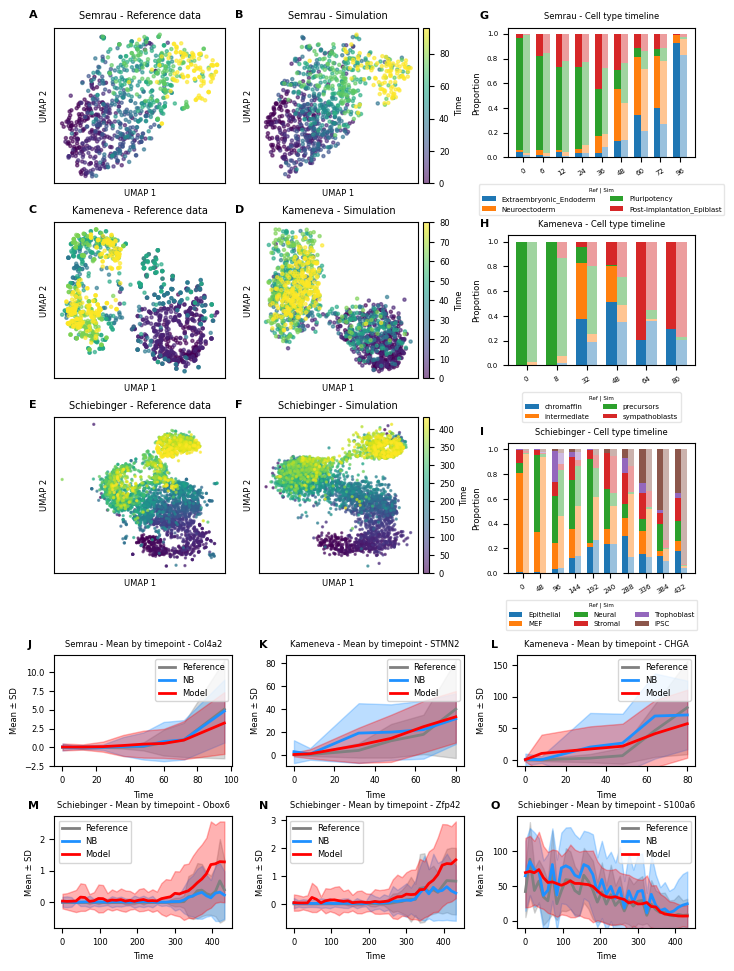

In [56]:
import matplotlib.gridspec as gridspec
from mpl_toolkits.axes_grid1 import make_axes_locatable

def plot_umap(ax, coords, colors, title, s=15, cmap='viridis', alpha=0.6, colorbar_option=False):
    sc = ax.scatter(coords[:, 0], coords[:, 1], c=colors, cmap=cmap, alpha=alpha, s=s)
    ax.set_xlabel('UMAP 1', fontsize=6)
    ax.set_ylabel('UMAP 2', fontsize=6)
    ax.set_title(title, fontsize=7)
    ax.set_xticks([])
    ax.set_yticks([])
    if colorbar_option:
        divider = make_axes_locatable(ax)
        cax = divider.append_axes('right', size='4%', pad=0.05)
        cb = plt.colorbar(sc, cax=cax, label='Time')
        cb.set_label('Time', fontsize=6)
        cb.ax.tick_params(labelsize=6)

def plot_gene_mean(ax, rna_traj, data_sim, time_vals, gene_idx, gene_name,
                   adata_beta=None, dataset_name=None):
    data_beta, time_beta = None, None
    if adata_beta is not None:
        data_beta = adata_beta.X.toarray() if scipy.sparse.issparse(adata_beta.X) else np.array(adata_beta.X)
        time_beta = np.array(adata_beta.obs['time'])

    t_beta = time_beta if time_beta is not None else time_vals
    curves = [
        (rna_traj[:, gene_idx],   time_vals, 'grey',       'Reference'),
        *([(data_beta[:, gene_idx], t_beta,  'dodgerblue', 'NB')] if data_beta is not None else []),
        (data_sim[:, gene_idx], time_vals, 'red',        'Model'),
    ]

    for vals, tvec, color, label in curves:
        ut = np.sort(np.unique(tvec))
        means = np.array([np.mean(vals[tvec == t]) for t in ut])
        stds  = np.array([np.std(vals[tvec == t])  for t in ut])
        ax.fill_between(ut, means - stds, means + stds, color=color, alpha=0.3)
        ax.plot(ut, means, color=color, linewidth=2, label=label)
    ax.set_xlabel('Time', fontsize=6)
    ax.set_ylabel('Mean ± SD', fontsize=6)
    prefix = f'{dataset_name} - ' if dataset_name else ''
    ax.set_title(f'{prefix}Mean by timepoint - {gene_name}', fontsize=6)
    ax.tick_params(axis='both', labelsize=6)
    ax.set_ylim(bottom=max(-10, ax.get_ylim()[0]))
    ax.legend(fontsize=6)

def plot_celltype_timeline(ax, adata_ref, adata_sim, title,
                           time_key='time', cell_type_key='cell_type',
                           max_timepoints=10):
    all_cts = sorted(
        set(adata_ref.obs[cell_type_key].astype(str).unique()) |
        set(adata_sim.obs[cell_type_key].astype(str).unique())
    )
    palette   = sns.color_palette('tab10', len(all_cts))
    color_map = {ct: palette[i] for i, ct in enumerate(all_cts)}

    times = np.sort(np.unique(adata_ref.obs[time_key]))

    if len(times) > max_timepoints:
        # Sample max_timepoints timepoints evenly spaced across the full range
        indices = np.round(np.linspace(0, len(times) - 1, max_timepoints)).astype(int)
        selected_times = times[indices]
        n_display     = max_timepoints
        display_times = selected_times
        ref_time_ser  = adata_ref.obs[time_key]
        sim_time_ser  = adata_sim.obs[time_key]
        get_mask_ref  = lambda b: ref_time_ser == selected_times[b]
        get_mask_sim  = lambda b: sim_time_ser == selected_times[b]
    else:
        n_display     = len(times)
        display_times = times
        ref_time_ser  = adata_ref.obs[time_key]
        sim_time_ser  = adata_sim.obs[time_key]
        get_mask_ref  = lambda b: ref_time_ser == times[b]
        get_mask_sim  = lambda b: sim_time_ser == times[b]

    x     = np.arange(n_display)
    width = 0.35

    bot_ref = np.zeros(n_display)
    bot_sim = np.zeros(n_display)
    handles, used_labels = [], []

    for ct in all_cts:
        prop_ref, prop_sim = [], []
        for b in range(n_display):
            mask_r = get_mask_ref(b)
            n_r    = mask_r.sum()
            prop_ref.append((adata_ref.obs.loc[mask_r, cell_type_key].astype(str) == ct).sum() / n_r
                            if n_r > 0 else 0)
            mask_s = get_mask_sim(b)
            n_s    = mask_s.sum()
            prop_sim.append((adata_sim.obs.loc[mask_s, cell_type_key].astype(str) == ct).sum() / n_s
                            if n_s > 0 else 0)
        prop_ref = np.array(prop_ref)
        prop_sim = np.array(prop_sim)

        bar = ax.bar(x - width / 2, prop_ref, width, bottom=bot_ref,
                     color=color_map[ct], label=ct)
        ax.bar(x + width / 2, prop_sim, width, bottom=bot_sim,
               color=color_map[ct], alpha=0.45, edgecolor='none')
        if ct not in used_labels:
            handles.append(bar)
            used_labels.append(ct)
        bot_ref += prop_ref
        bot_sim += prop_sim

    # Set xticks as int
    ax.set_xticks(x)
    ax.set_xticklabels([f'{int(t)}' for t in display_times], fontsize=4, rotation=30)
    ax.set_ylabel('Proportion', fontsize=6)
    ax.set_ylim(0, 1.05)
    ax.set_title(title, fontsize=6)
    ax.tick_params(axis='both', labelsize=5)
    # compact legend: solid = reference, transparent = simulation
    n_cols = max(1, len(used_labels) // 2)
    ax.legend(handles=handles, labels=used_labels,
              fontsize=5, loc='upper center', ncol=n_cols,
              bbox_to_anchor=(0.5, -0.18),
              title='Ref | Sim', title_fontsize=4, framealpha=0.5)

# ── Layout ───────────────────────────────────────────────────────────────────
fig = plt.figure(figsize=(8.27, 11.69))
gs   = gridspec.GridSpec(2, 2, figure=fig, height_ratios=[3, 1.5], width_ratios=[2, 1],
                         hspace=0.2, wspace=0.28)
gs01 = gs[0, 0].subgridspec(3, 2, hspace=0.25, wspace=0.2)
gs02 = gs[0, 1].subgridspec(3, 1, hspace=0.6, wspace=0.3)
gs03 = gs[1, :].subgridspec(2, 3, hspace=0.45, wspace=0.3)

axes = (
    [fig.add_subplot(gs01[r, c]) for r in range(3) for c in range(2)] +
    [fig.add_subplot(gs02[r, 0]) for r in range(3)] +
    [fig.add_subplot(gs03[r, c]) for r in range(2) for c in range(3) ]
)

for ax, label in zip(axes, "ABCDEFGHIJKLMNO"):
    ax.text(-0.15, 1.05, label, transform=ax.transAxes,
            ha="left", va="bottom", fontsize=8, fontweight="bold", clip_on=False)

# ── UMAP panels (A–F) ────────────────────────────────────────────────────────
umap_configs = [
    (axes[0], data_semrau_traj_2d,      time_semrau[subsample_semrau],      'Semrau - Reference data', 5, False),
    (axes[1], sim_semrau_traj_2d,       time_semrau[subsample_semrau],      'Semrau - Simulation', 5, True),
    (axes[2], data_olivier_traj_2d,     time_olivier[subsample_olivier],     'Kameneva - Reference data', 5, False),
    (axes[3], sim_olivier_traj_2d,      time_olivier[subsample_olivier],     'Kameneva - Simulation', 5, True),
    (axes[4], data_schiebinger_traj_2d, time_schiebinger[subsample_schiebinger], 'Schiebinger - Reference data', 2, False),
    (axes[5], sim_schiebinger_traj_2d,  time_schiebinger[subsample_schiebinger], 'Schiebinger - Simulation', 2, True),
]
for ax, coords, time, title, s, colorbar_option in umap_configs:
    plot_umap(ax, coords, time, title, s=s, colorbar_option=colorbar_option)

# ── Cell-type composition timeline panels (G–I) ──────────────────────────────
celltype_configs = [
    (axes[6], adata_semrau,      adata_sim_semrau,      'Semrau - Cell type timeline'),
    (axes[7], adata_olivier,     adata_sim_olivier,     'Kameneva - Cell type timeline'),
    (axes[8], adata_schiebinger, adata_sim_schiebinger, 'Schiebinger - Cell type timeline'),
]
for ax, adata_ref, adata_sim_data, title in celltype_configs:
    plot_celltype_timeline(ax, adata_ref, adata_sim_data, title)

# ── Gene mean/SD panels (J–O) ─────────────────────────────────────────────────
gene_plot_configs = [
    (axes[9:10],  rna_traj_semrau,      data_sim_semrau,      time_semrau,      adata_semrau,      adata_beta_semrau,      [4],   'Semrau'),
    (axes[10:12], rna_traj_olivier,     data_sim_olivier,     time_olivier,     adata_olivier,     adata_beta_olivier,     [86, 12],  'Kameneva'),
    (axes[12:15], rna_traj_schiebinger, data_sim_schiebinger, time_schiebinger, adata_schiebinger, adata_beta_schiebinger, [71, 107, 83], 'Schiebinger'),
]
for ax_slice, rna_traj, data_sim, time_vals, adata, adata_beta, gene_indices, dataset_name in gene_plot_configs:
    for ax, gene_idx in zip(ax_slice, gene_indices):
        plot_gene_mean(ax, rna_traj, data_sim, time_vals, gene_idx,
                       adata.var_names[gene_idx], adata_beta=adata_beta,
                       dataset_name=dataset_name)

plt.savefig('figure_6.pdf', dpi=300, bbox_inches='tight')
plt.show()


# Check genes

In [37]:
# Compute variance of expression across time for each gene
unique_times = np.sort(np.unique(time_semrau))

# For reference data
var_expr_data = []
for gene_idx in range(adata_semrau.n_vars):
    gene_vals = rna_traj_semrau[:, gene_idx]
    timepoint_means = [np.mean(gene_vals[time_semrau == t]) for t in unique_times]
    var_expr_data.append(np.var(timepoint_means))
var_expr_data = np.array(var_expr_data)

# For simulated data
var_expr_sim = []
for gene_idx in range(data_sim_semrau.shape[1]):
    gene_vals = data_sim_semrau[:, gene_idx]
    timepoint_means = [np.mean(gene_vals[time_semrau == t]) for t in unique_times]
    var_expr_sim.append(np.var(timepoint_means))
var_expr_sim = np.array(var_expr_sim)

# Get top 10 most variable genes for reference data
top10_indices_data = np.argsort(var_expr_data)[-10:][::-1]
top10_genes_data = adata_semrau.var_names[top10_indices_data]
top10_values_data = var_expr_data[top10_indices_data]

# Get top 10 most variable genes for simulated data
top10_indices_sim = np.argsort(var_expr_sim)[-10:][::-1]
top10_genes_sim = adata_semrau.var_names[top10_indices_sim]
top10_values_sim = var_expr_sim[top10_indices_sim]

print("Top 10 most variable genes across time in reference data (adata_schiebinger):")
for i, (idx, gene, val) in enumerate(zip(top10_indices_data, top10_genes_data, top10_values_data), 1):
    print(f"{i}. {gene} (index {idx}): variance = {val:.2f}")

print("\nTop 10 most variable genes across time in simulated data (data_sim_schiebinger):")
for i, (idx, gene, val) in enumerate(zip(top10_indices_sim, top10_genes_sim, top10_values_sim), 1):
    print(f"{i}. {gene} (index {idx}): variance = {val:.2f}")

Top 10 most variable genes across time in reference data (adata_schiebinger):
1. Sparc (index 36): variance = 25.40
2. Lamb1 (index 23): variance = 8.70
3. Zfp42 (index 38): variance = 2.61
4. Col4a2 (index 4): variance = 2.43
5. Sox2 (index 34): variance = 1.43
6. Jarid2 (index 19): variance = 0.75
7. Esrrb (index 11): variance = 0.73
8. Pou5f1 (index 30): variance = 0.60
9. Klf2 (index 20): variance = 0.58
10. Klf4 (index 21): variance = 0.54

Top 10 most variable genes across time in simulated data (data_sim_schiebinger):
1. Sparc (index 36): variance = 15.13
2. Lamb1 (index 23): variance = 5.13
3. Zfp42 (index 38): variance = 2.14
4. Sox2 (index 34): variance = 1.31
5. Col4a2 (index 4): variance = 0.93
6. Jarid2 (index 19): variance = 0.48
7. Esrrb (index 11): variance = 0.48
8. Klf2 (index 20): variance = 0.38
9. Pou5f1 (index 30): variance = 0.37
10. Klf4 (index 21): variance = 0.36
